In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('raw_data/train.csv')
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [5]:
df.shape

(159571, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [7]:
df.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
df.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

## Class Distribution

In [11]:
labels = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]
df[labels].sum()

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

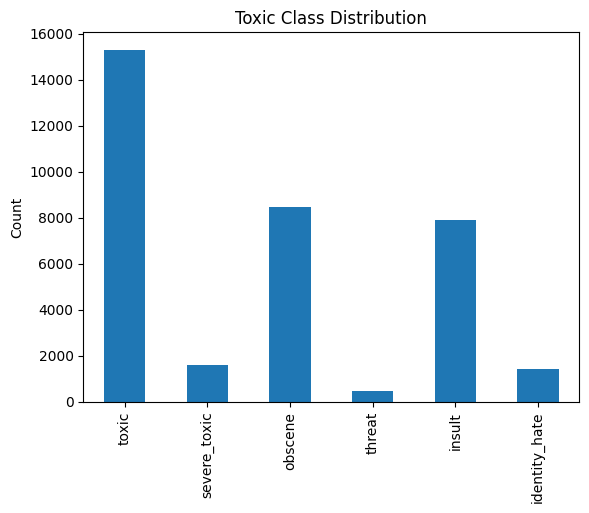

In [12]:
df[labels].sum().plot(kind='bar')

plt.title("Toxic Class Distribution")
plt.ylabel("Count")
plt.show()

## Number of toxic labels per comment
* A comment can belong to multiole categories.

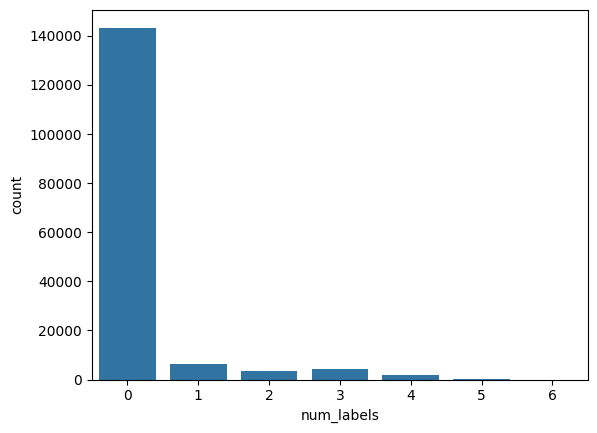

In [17]:
df['num_labels'] = df[labels].sum(axis=1)
sns.countplot(x='num_labels', data=df)
plt.show()

In [18]:
df['num_labels'].value_counts()

num_labels
0    143346
1      6360
3      4209
2      3480
4      1760
5       385
6        31
Name: count, dtype: int64

## Toxic vs non - toxic distribution

In [20]:
df['clean'] = (df[labels].sum(axis=1) == 0).astype(int)
df['clean'].value_counts()

clean
1    143346
0     16225
Name: count, dtype: int64

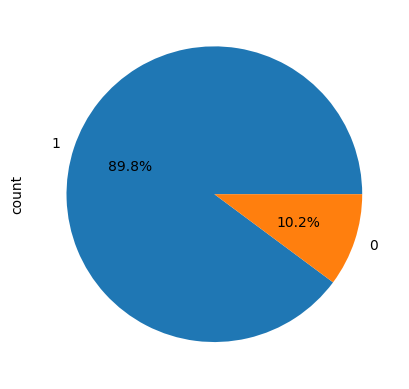

In [21]:
df['clean'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.show()

## Correlation between toxic labels

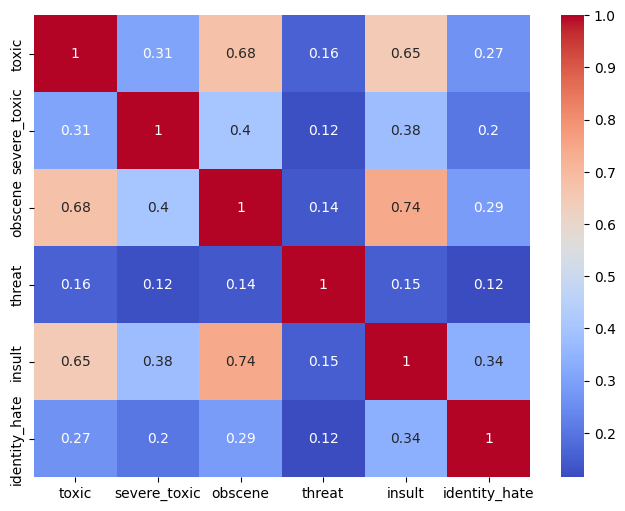

In [22]:
corr = df[labels].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

## Most Frequent Words

In [23]:
from collections import Counter

all_words = " ".join(df['comment_text'])

words = all_words.lower().split()

Counter(words).most_common(20)

[('the', 490031),
 ('to', 294069),
 ('of', 222834),
 ('and', 218120),
 ('a', 211778),
 ('i', 196695),
 ('you', 187782),
 ('is', 170753),
 ('that', 146478),
 ('in', 140540),
 ('it', 109868),
 ('for', 100838),
 ('not', 88645),
 ('this', 88288),
 ('on', 87129),
 ('be', 81887),
 ('"', 81755),
 ('as', 75524),
 ('have', 71273),
 ('are', 70102)]

## Toxic Comments WordCloud

In [27]:
!pip install wordcloud

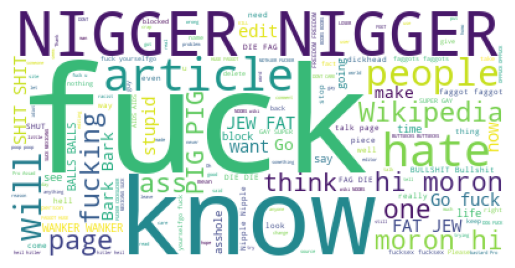

In [28]:
from wordcloud import WordCloud
toxic_comments = df[df['toxic']==1]

text = " ".join(
    toxic_comments['comment_text']
)

wordcloud = WordCloud(
    background_color='white'
).generate(text)

plt.imshow(wordcloud)
plt.axis('off')
plt.show()

## Severe Toxic Wor Cloud

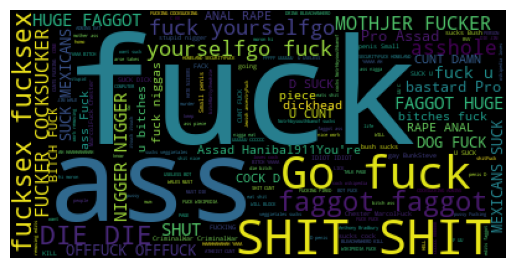

In [34]:
severe_text = " ".join(
    df[df['severe_toxic']==1]['comment_text']
)

severe_toxic_word_cloud = WordCloud().generate(severe_text)
plt.imshow(severe_toxic_word_cloud)
plt.axis('off')
plt.show()

## Check Duplicate Comments

In [35]:
duplicates = df.duplicated(
    subset=['comment_text']
).sum()

print(duplicates)

0


## Percentage of each label

In [36]:
for label in labels:
    percentage = (
        df[label].mean()*100
    )

    print(
        f"{label}: {percentage:.2f}%"
    )

toxic: 9.58%
severe_toxic: 1.00%
obscene: 5.29%
threat: 0.30%
insult: 4.94%
identity_hate: 0.88%


## Multi-Label Combinations

In [37]:
df['label_combo'] = df[labels].astype(str).agg(
    '-'.join,
    axis=1
)

df['label_combo'].value_counts().head(10)

label_combo
0-0-0-0-0-0    143346
1-0-0-0-0-0      5666
1-0-1-0-1-0      3800
1-0-1-0-0-0      1758
1-0-0-0-1-0      1215
1-1-1-0-1-0       989
1-0-1-0-1-1       618
0-0-1-0-0-0       317
0-0-0-0-1-0       301
1-1-1-0-1-1       265
Name: count, dtype: int64